In [1]:
import pandas as pd
import numpy as np

# Load raw data
df_raw = pd.read_excel("Dump Dataset.xlsx")
 # adjust path



In [31]:
# --- Canonical completion definition ---

df_raw['Delivery Completion'] = df_raw['Status'].apply(
    lambda x: 'COMPLETED' if x == 'DELIVERED' else 'NOT_COMPLETED'
)

# Keep only successfully delivered orders
df_completed = df_raw[df_raw["Delivery Completion"] == "COMPLETED"].copy()

# Parse dates
df_completed["order_date"] = pd.to_datetime(df_completed["Created at"])
df_completed["delivery_date"] = pd.to_datetime(df_completed["Delivery Date"])

# Remove rows with missing or invalid dates
df_completed = df_completed[
    df_completed["order_date"].notna() &
    df_completed["delivery_date"].notna()
]

# Derive delivery duration
df_completed["actual_delivery_days"] = (
    df_completed["delivery_date"] - df_completed["order_date"]
).dt.days

# Remove non-sensical durations
df_completed = df_completed[df_completed["actual_delivery_days"] >= 0]

# Clean Max Tat (string -> numeric)
df_completed["Max Tat"] = (
    df_completed["Max Tat"]
      .astype(str)
      .str.strip()
)

df_completed["Max Tat"] = pd.to_numeric(df_completed["Max Tat"], errors="coerce")

# Drop rows with missing Max Tat
before = len(df_completed)
df_completed = df_completed[df_completed["Max Tat"].notna()].copy()
after = len(df_completed)

print(f"Dropped {before - after} rows due to missing Max Tat")




# Target variable
df_completed["delayed"] = (
    df_completed["actual_delivery_days"] > df_completed["Max Tat"]
).astype(int)

# Supporting features
df_completed["interstate_flag"] = (
    df_completed["Pickup State"].astype(str).str.upper() !=
    df_completed["Drop State"].astype(str).str.upper()
).astype(int)

df_completed["shipment_volume"] = (
    df_completed["Shipment Length"] *
    df_completed["Shipment Breadth"] *
    df_completed["Shipment Height"]
)

print("Rows in raw data:", len(df_raw))
print("Rows in completed deliveries:", len(df_completed))

Dropped 3329 rows due to missing Max Tat
Rows in raw data: 264171
Rows in completed deliveries: 213808


In [32]:
assert df_completed["actual_delivery_days"].isna().sum() == 0
assert df_completed["delayed"].isna().sum() == 0

df_completed[["actual_delivery_days", "Max Tat"]].describe()


,actual_delivery_days,Max Tat
count,213808.000000,213808.000000
mean,3.744490,4.631674
std,2.538508,2.059514
min,0.000000,0.000000
25%,2.000000,3.000000
50%,3.000000,5.000000
75%,5.000000,6.000000
max,63.000000,9.000000


In [33]:
courier_features = (
    df_completed.groupby("Courier Partner")
      .agg(
          shipments=("delayed", "count"),
          delay_rate=("delayed", "mean"),
          avg_delivery_days=("actual_delivery_days", "mean"),
          delivery_std=("actual_delivery_days", "std"),
          avg_max_tat=("Max Tat", "mean"),
          pct_interstate=("interstate_flag", "mean"),
          avg_weight=("Shipment Weight", "mean")
      )
      .reset_index()
)

courier_features = courier_features[courier_features["shipments"] >= 100].copy()
courier_features["delivery_std"] = courier_features["delivery_std"].fillna(0)

courier_features.head()


,Courier Partner,shipments,delay_rate,avg_delivery_days,delivery_std,avg_max_tat,pct_interstate,avg_weight
0,ATS Surface,11358,0.121324,4.845836,2.147815,6.641574,0.909139,797.518489
1,Blitz,727,0.125172,1.059147,0.939240,1.268226,0.440165,1216.266850
2,Blitz SDD,1189,0.560135,0.843566,1.472790,0.000000,0.305299,1580.445753
3,Bluedart Air,25031,0.302105,3.182973,2.288989,3.056330,0.904079,892.317722
4,Bluedart Surface,27384,0.134714,3.680543,2.204160,5.572195,0.813395,599.082777


In [34]:
df_raw["Max Tat"].astype(str).value_counts().head(10)

Max Tat
6    65212
5    44492
2    36745
7    33763
3    31516
4    20921
1    14244
9     9407
      3964
8     2174
Name: count, dtype: int64

In [35]:
df_completed[["actual_delivery_days", "Max Tat", "delayed"]].describe()


,actual_delivery_days,Max Tat,delayed
count,213808.000000,213808.000000,213808.000000
mean,3.744490,4.631674,0.202247
std,2.538508,2.059514,0.401676
min,0.000000,0.000000,0.000000
25%,2.000000,3.000000,0.000000
50%,3.000000,5.000000,0.000000
75%,5.000000,6.000000,0.000000
max,63.000000,9.000000,1.000000


In [36]:
courier_features = (
    df_completed.groupby("Courier Partner")
      .agg(
          shipments=("delayed", "count"),
          delay_rate=("delayed", "mean"),
          avg_delivery_days=("actual_delivery_days", "mean"),
          delivery_std=("actual_delivery_days", "std"),
          avg_max_tat=("Max Tat", "mean"),
          pct_interstate=("interstate_flag", "mean"),
          avg_weight=("Shipment Weight", "mean")
      )
      .reset_index()
)


In [37]:
courier_features = courier_features[courier_features["shipments"] >= 100].copy()

# std can be NaN for couriers with exactly 1 record after filtering
courier_features["delivery_std"] = courier_features["delivery_std"].fillna(0)

print("Couriers retained:", courier_features.shape[0])

Couriers retained: 19


In [38]:
cluster_cols = [
    "delay_rate",
    "avg_delivery_days",
    "delivery_std",
    "avg_max_tat",
    "pct_interstate",
    "avg_weight"
]

assert courier_features[cluster_cols].isna().sum().sum() == 0
courier_features[cluster_cols].describe()

,delay_rate,avg_delivery_days,delivery_std,avg_max_tat,pct_interstate,avg_weight
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,0.284734,3.307914,2.282694,3.383865,0.663386,1345.713259
std,0.208190,1.706346,0.930384,2.112022,0.311842,1648.091132
min,0.094340,0.688679,0.785138,0.000000,0.009469,198.744902
25%,0.149602,1.328103,1.596256,1.143547,0.558805,553.055908
50%,0.203577,3.849948,2.311673,4.039823,0.762400,892.317722
75%,0.343495,4.386040,2.805739,5.060848,0.897064,1174.248588
max,0.963576,6.227447,4.498790,6.641574,0.992655,6556.206971


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(courier_features[cluster_cols])

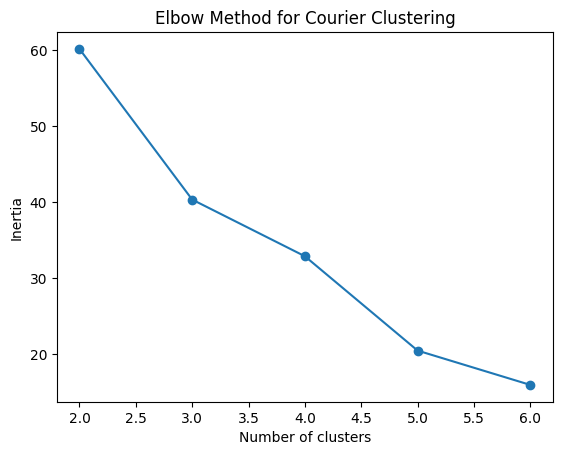

In [40]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 7), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Courier Clustering")
plt.show()


In [41]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
courier_features["courier_cluster"] = kmeans.fit_predict(X_scaled)

In [42]:
courier_features.groupby("courier_cluster").agg(
    couriers=("Courier Partner", "nunique"),
    shipments=("shipments", "sum"),
    avg_delay_rate=("delay_rate", "mean"),
    avg_delivery_days=("avg_delivery_days", "mean"),
    avg_std=("delivery_std", "mean"),
    avg_max_tat=("avg_max_tat", "mean"),
    avg_weight=("avg_weight", "mean")
)


,couriers,shipments,avg_delay_rate,avg_delivery_days,avg_std,avg_max_tat,avg_weight
courier_cluster,,,,,,,
0,12,198084,0.263455,4.316792,2.625609,4.821467,1296.754750
1,6,15333,0.214152,1.058918,1.227516,1.033454,1513.589662
2,1,302,0.963576,4.695364,4.498790,0.235099,925.956954


In [43]:
courier_features["courier_mode"] = courier_features["courier_cluster"].map({
    0: "Surface_backbone",
    1: "Express_like",
    2: "Exception_high_risk"
})


In [44]:
courier_features.columns

Index(['Courier Partner', 'shipments', 'delay_rate', 'avg_delivery_days',
       'delivery_std', 'avg_max_tat', 'pct_interstate', 'avg_weight',
       'courier_cluster', 'courier_mode'],
      dtype='object')

In [45]:
df_completed = df_completed.merge(
    courier_features[["Courier Partner", "courier_mode"]],
    on="Courier Partner",
    how="left"
)

In [46]:
df_completed["courier_mode"] = df_completed["courier_mode"].fillna("Unknown")

Courier behavior clustering resulted in three distinct groups. The largest cluster represents surface-backbone couriers characterized by moderate delivery speed and stable performance. A second cluster represents express-like couriers with significantly faster deliveries but tighter promise windows, making them more sensitive to disruptions. A third, small cluster exhibited extreme delay rates driven by unrealistically tight service-level commitments and was treated as an exception category rather than a standard transport mode.

In [49]:
from sklearn.model_selection import train_test_split

features_common = [
    "Shipment Weight",
    "shipment_volume",
    "interstate_flag",
    "Max Tat"
]

target = "delayed"

df_model = df_completed.copy()

X = df_model[features_common + ["Courier Partner", "courier_mode"]]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [48]:
set(["delayed", "courier_mode"]).issubset(df_completed.columns)


True

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


In [53]:
num_features = features_common
cat_features_A = ["Courier Partner"]

preprocess_A = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_A)
    ]
)

model_A = Pipeline(
    steps=[
        ("prep", preprocess_A),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)


In [54]:
cat_features_B = ["courier_mode"]

preprocess_B = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_B)
    ]
)

model_B = Pipeline(
    steps=[
        ("prep", preprocess_B),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)


In [55]:
model_A.fit(X_train, y_train)
model_B.fit(X_train, y_train)


c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [56]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate(model, X_test, y_test, label):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {label} =====")
    print(classification_report(y_test, preds, digits=4))
    print("ROC AUC:", roc_auc_score(y_test, probs))


In [57]:
evaluate(model_A, X_test, y_test, "Model A — Courier Name")
evaluate(model_B, X_test, y_test, "Model B — Courier Mode")



===== Model A — Courier Name =====
              precision    recall  f1-score   support

           0     0.8667    0.6658    0.7531     34114
           1     0.3114    0.5962    0.4091      8648

    accuracy                         0.6517     42762
   macro avg     0.5891    0.6310    0.5811     42762
weighted avg     0.7544    0.6517    0.6835     42762

ROC AUC: 0.6873644183834394

===== Model B — Courier Mode =====
              precision    recall  f1-score   support

           0     0.8561    0.6519    0.7402     34114
           1     0.2925    0.5678    0.3861      8648

    accuracy                         0.6349     42762
   macro avg     0.5743    0.6098    0.5631     42762
weighted avg     0.7421    0.6349    0.6686     42762

ROC AUC: 0.6692145823626576


While courier behavior clustering revealed meaningful operational regimes, replacing courier identity with the clustered transport proxy resulted in a modest decline in predictive performance. This indicates that courier-specific nuances provide additional predictive signal beyond broad transport categories. Consequently, courier identity was retained for prediction, while the clustered courier mode was used to enhance interpretability and business insight.